In [1]:
# Cell 1: Imports & basic config

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import IsolationForest

os.chdir("/Users/wasnaafarag/Desktop/Finance-Fraud-Detection")
print("Current working directory set to:")
print(os.getcwd())

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)


Current working directory set to:
/Users/wasnaafarag/Desktop/Finance-Fraud-Detection


In [2]:
# Cell 2: Load transaction and identity tables

import pandas as pd

TRANSACTION_PATH = "train_transaction.csv"
IDENTITY_PATH    = "train_identity.csv"

print("[+] Loading CSV files...")

df_transaction = pd.read_csv(TRANSACTION_PATH)
df_identity    = pd.read_csv(IDENTITY_PATH)

print("Transaction shape:", df_transaction.shape)
print("Identity shape   :", df_identity.shape)

df_transaction.head()



[+] Loading CSV files...
Transaction shape: (590540, 394)
Identity shape   : (144233, 41)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Cell 3: Merge tables on TransactionID

print("[+] Merging transaction and identity data on TransactionID...")
df = df_transaction.merge(df_identity, on="TransactionID", how="left")

print("Merged shape:", df.shape)
print(df[["TransactionID", "isFraud"]].head())

fraud_ratio = df["isFraud"].mean()
print(f"[+] Overall fraud ratio: {fraud_ratio:.4%}")


[+] Merging transaction and identity data on TransactionID...
Merged shape: (590540, 434)
   TransactionID  isFraud
0        2987000        0
1        2987001        0
2        2987002        0
3        2987003        0
4        2987004        0
[+] Overall fraud ratio: 3.4990%


In [ ]:
# Cell 4: memory optimisation (downcast numeric columns)

def reduce_mem_usage(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object and not str(col_type).startswith("category"):
            c_min = df[col].min()
            c_max = df[col].max()

            if str(col_type).startswith("int") or str(col_type).startswith("Int"):
                if c_min >= 0:
                    if c_max < 2**8:
                        df[col] = df[col].astype(np.uint8)
                    elif c_max < 2**16:
                        df[col] = df[col].astype(np.uint16)
                    elif c_max < 2**32:
                        df[col] = df[col].astype(np.uint32)
                    else:
                        df[col] = df[col].astype(np.uint64)
                else:
                    if np.iinfo(np.int8).min <= c_min and c_max <= np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif np.iinfo(np.int16).min <= c_min and c_max <= np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif np.iinfo(np.int32).min <= c_min and c_max <= np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    else:
                        df[col] = df[col].astype(np.int64)
            else:
                df[col] = df[col].astype(np.float32)

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f"[+] Mem usage decreased from {start_mem:.2f} MB to {end_mem:.2f} MB "
              f"({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)")
    return df

df = reduce_mem_usage(df)


[+] Mem usage decreased from 1955.37 MB to 1044.70 MB (46.6% reduction)


In [ ]:
# Cell 5: Keep features + target, basic info

TARGET_COL = "isFraud"

# I keep everything except the target; TransactionID I'll drop later as non-feature
print("[+] Columns summary:")
print("Total columns:", df.shape[1])
print("Example columns:", df.columns[:20].tolist())

print("\n[+] Target distribution:")
print(df[TARGET_COL].value_counts(normalize=True).rename("ratio"))


[+] Columns summary:
Total columns: 434
Example columns: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3']

[+] Target distribution:
isFraud
0    0.96501
1    0.03499
Name: ratio, dtype: float64


In [6]:
# Cell 6: Downsample to a manageable subset: all fraud + sampled normals

N_NORMAL = 200_000  # adjust if your RAM allows more / fewer

fraud_df = df[df[TARGET_COL] == 1]
normal_df = df[df[TARGET_COL] == 0]

print("[+] Original class counts:")
print("Fraud :", len(fraud_df))
print("Normal:", len(normal_df))

# Sample from normals
normal_sample = normal_df.sample(
    n=min(N_NORMAL, len(normal_df)),
    random_state=RANDOM_STATE
)

df_small = pd.concat([fraud_df, normal_sample], axis=0).sample(
    frac=1.0, random_state=RANDOM_STATE
).reset_index(drop=True)

print("\n[+] Subset shape:", df_small.shape)
print(df_small[TARGET_COL].value_counts())
print(df_small[TARGET_COL].value_counts(normalize=True).rename("ratio"))


[+] Original class counts:
Fraud : 20663
Normal: 569877

[+] Subset shape: (220663, 434)
isFraud
0    200000
1     20663
Name: count, dtype: int64
isFraud
0    0.906359
1    0.093641
Name: ratio, dtype: float64


In [7]:
# Cell 7: Split features/target & identify numeric vs categorical columns

# Drop TransactionID from features (ID-like, not predictive)
feature_cols = [c for c in df_small.columns if c not in ["TransactionID", TARGET_COL]]

X = df_small[feature_cols].copy()
y = df_small[TARGET_COL].copy()

# Identify column types
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

print("[+] Total features:", len(feature_cols))
print("  - Numeric     :", len(num_cols))
print("  - Categorical :", len(cat_cols))


[+] Total features: 432
  - Numeric     : 401
  - Categorical : 31


In [8]:
# Cell 8: Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=RANDOM_STATE
)

print("[+] Train shape:", X_train.shape)
print("[+] Test shape :", X_test.shape)

print("\n[+] Train fraud ratio:", y_train.mean())
print("[+] Test fraud ratio :", y_test.mean())


[+] Train shape: (154464, 432)
[+] Test shape : (66199, 432)

[+] Train fraud ratio: 0.09363994199295629
[+] Test fraud ratio : 0.09364189791386576


In [9]:
# Cell 9: Preprocessing pipeline with ColumnTransformer

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        (
            "ordinal",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

print("[+] Preprocessor defined.")


[+] Preprocessor defined.


In [10]:
# Cell 10: Fit preprocessor on train, transform train & test

print("[+] Fitting preprocessor on training data...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape :", X_test_processed.shape)


[+] Fitting preprocessor on training data...
Processed train shape: (154464, 432)
Processed test shape : (66199, 432)


In [ ]:
# Cell 11: Train Isolation Forest on normal-only training data

# Use only non-fraud samples from training set for IF training (unsupervised)
normal_mask = (y_train == 0)
X_train_normal = X_train_processed[normal_mask]

train_fraud_ratio = y_train.mean()
print(f"[+] Train fraud ratio: {train_fraud_ratio:.4%}")

# Reasonable starting contamination near overall test fraud ratio
CONTAMINATION = float(train_fraud_ratio)  

iso_forest = IsolationForest(
    n_estimators=100,
    max_samples="auto",
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("[+] Training Isolation Forest on normal-only training data...")
iso_forest.fit(X_train_normal)

print("[+] Model training done.")


[+] Train fraud ratio: 9.3640%
[+] Training Isolation Forest on normal-only training data...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   2 out of  12 | elapsed:    0.1s remaining:    0.7s
[Parallel(n_jobs=12)]: Done  12 out of  12 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s


[+] Model training done.


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.5s finished


In [12]:
# Cell 12: Inference on test set – anomaly scores and predictions

print("[+] Computing anomaly scores on test set...")
# Higher score = more normal -> we invert sign so that higher = more anomalous
raw_scores = iso_forest.decision_function(X_test_processed)
anomaly_scores = -raw_scores

# IsolationForest's own binary predictions: -1 (anomaly) / 1 (normal)
raw_pred = iso_forest.predict(X_test_processed)

# Map to fraud labels: 1 = fraud (anomaly), 0 = normal
y_pred_if = (raw_pred == -1).astype(int)

print("[+] Example scores & predictions:")
for i in range(5):
    print(f"  Score: {anomaly_scores[i]:.4f}, Pred: {y_pred_if[i]}, True: {y_test.iloc[i]}")


[+] Computing anomaly scores on test set...


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.3s finished


[+] Example scores & predictions:
  Score: -0.0978, Pred: 0, True: 0
  Score: -0.0206, Pred: 0, True: 1
  Score: 0.2513, Pred: 1, True: 0
  Score: -0.0680, Pred: 0, True: 0
  Score: -0.0950, Pred: 0, True: 0


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


In [13]:
# Cell 13: Evaluate model on test set

cm = confusion_matrix(y_test, y_pred_if)
tn, fp, fn, tp = cm.ravel()

print("=== Confusion Matrix ===")
print(cm)
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}\n")

print("=== Classification Report ===")
print(classification_report(y_test, y_pred_if, digits=4))

# ROC-AUC using anomaly scores (higher = more anomalous)
roc_auc = roc_auc_score(y_test, anomaly_scores)
print(f"ROC-AUC (using anomaly scores): {roc_auc:.4f}")

# PR curve + PR-AUC (focuses on fraud class)
precision, recall, thresholds = precision_recall_curve(y_test, anomaly_scores)
pr_auc = auc(recall, precision)
print(f"PR-AUC (fraud class): {pr_auc:.4f}")


=== Confusion Matrix ===
[[54454  5546]
 [ 3419  2780]]
TN: 54454, FP: 5546, FN: 3419, TP: 2780

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9409    0.9076    0.9239     60000
           1     0.3339    0.4485    0.3828      6199

    accuracy                         0.8646     66199
   macro avg     0.6374    0.6780    0.6534     66199
weighted avg     0.8841    0.8646    0.8733     66199

ROC-AUC (using anomaly scores): 0.7671
PR-AUC (fraud class): 0.3055


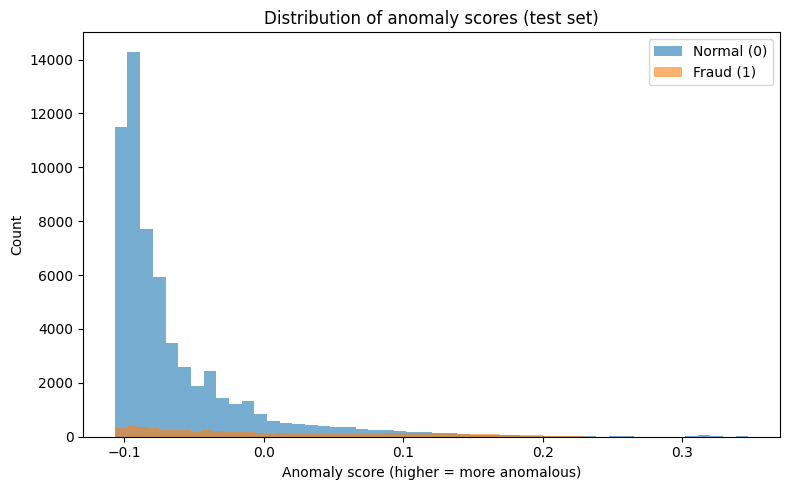

In [14]:
# Cell 14: Histogram of anomaly scores for fraud vs normal

fraud_scores  = anomaly_scores[y_test.values == 1]
normal_scores = anomaly_scores[y_test.values == 0]

plt.figure(figsize=(8, 5))
plt.hist(normal_scores, bins=50, alpha=0.6, label="Normal (0)")
plt.hist(fraud_scores,  bins=50, alpha=0.6, label="Fraud (1)")
plt.xlabel("Anomaly score (higher = more anomalous)")
plt.ylabel("Count")
plt.title("Distribution of anomaly scores (test set)")
plt.legend()
plt.tight_layout()
plt.show()


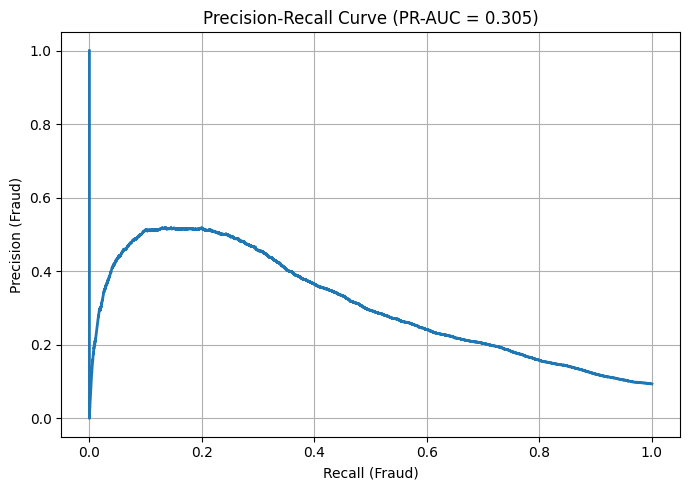

In [15]:
# Cell 15: Precision-Recall curve (fraud = positive class)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall (Fraud)")
plt.ylabel("Precision (Fraud)")
plt.title(f"Precision-Recall Curve (PR-AUC = {pr_auc:.3f})")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Cell 16 : Threshold tuning on anomaly scores

def evaluate_at_threshold(scores, y_true, threshold):
    """
    scores: anomaly scores (higher = more anomalous)
    threshold: classify as fraud if score >= threshold
    """
    y_pred_custom = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_custom)
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    return {
        "threshold": threshold,
        "precision": prec,
        "recall": rec,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

# Try a few quantile-based thresholds
quantiles = [0.80, 0.85, 0.90, 0.95, 0.98]
print("=== Threshold tuning (quantile of anomaly scores) ===")
results = []
for q in quantiles:
    thr = np.quantile(anomaly_scores, q)
    metrics = evaluate_at_threshold(anomaly_scores, y_test.values, thr)
    results.append(metrics)
    print(f"Quantile {q:.2f}, Threshold {thr:.4f}, "
          f"Precision {metrics['precision']:.3f}, Recall {metrics['recall']:.3f}, "
          f"TP {metrics['tp']}, FP {metrics['fp']}, FN {metrics['fn']}, TN {metrics['tn']}")


=== Threshold tuning (quantile of anomaly scores) ===
Quantile 0.80, Threshold -0.0320, Precision 0.262, Recall 0.560, TP 3470, FP 9770, FN 2729, TN 50230
Quantile 0.85, Threshold -0.0121, Precision 0.303, Recall 0.486, TP 3013, FP 6917, FN 3186, TN 53083
Quantile 0.90, Threshold 0.0226, Precision 0.369, Recall 0.394, TP 2444, FP 4176, FN 3755, TN 55824
Quantile 0.95, Threshold 0.0854, Precision 0.489, Recall 0.261, TP 1617, FP 1693, FN 4582, TN 58307
Quantile 0.98, Threshold 0.1441, Precision 0.512, Recall 0.109, TP 678, FP 646, FN 5521, TN 59354


In [17]:
# Cell 17 (optional): Clean summary for your report

print("========== SUMMARY ==========")
print(f"Train samples: {X_train.shape[0]}  (fraud ratio: {y_train.mean():.4%})")
print(f"Test  samples: {X_test.shape[0]}  (fraud ratio: {y_test.mean():.4%})")
print()
print(f"IsolationForest contamination: {CONTAMINATION:.4f}")
print(f"Test ROC-AUC (anomaly scores): {roc_auc:.4f}")
print(f"Test PR-AUC  (fraud class):    {pr_auc:.4f}")
print()
print("Confusion matrix (IF default predict):")
print(cm)


========== SUMMARY ==========
Train samples: 154464  (fraud ratio: 9.3640%)
Test  samples: 66199  (fraud ratio: 9.3642%)

IsolationForest contamination: 0.0936
Test ROC-AUC (anomaly scores): 0.7671
Test PR-AUC  (fraud class):    0.3055

Confusion matrix (IF default predict):
[[54454  5546]
 [ 3419  2780]]


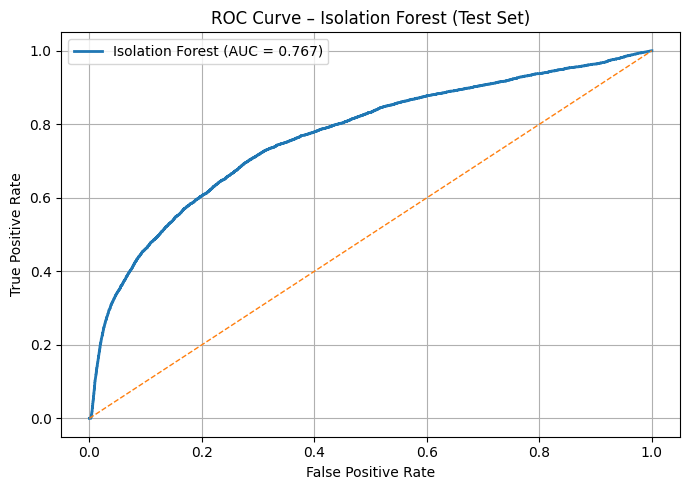

In [18]:
# Cell 18: ROC curve for Isolation Forest (using anomaly scores)

from sklearn.metrics import roc_curve

# fpr = false positive rate, tpr = true positive rate
fpr, tpr, roc_thresholds = roc_curve(y_test, anomaly_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"Isolation Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Isolation Forest (Test Set)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


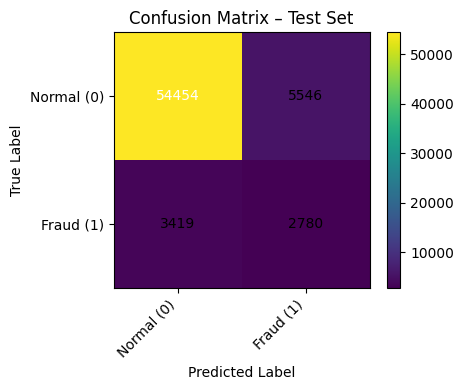

In [19]:
# Cell 19: Confusion matrix heatmap (test set)

import numpy as np

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest")
ax.set_title("Confusion Matrix – Test Set")
plt.colorbar(im, ax=ax)

classes = ["Normal (0)", "Fraud (1)"]
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticklabels(classes)

# Print numbers in each cell
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > thresh else "black",
        )

ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()


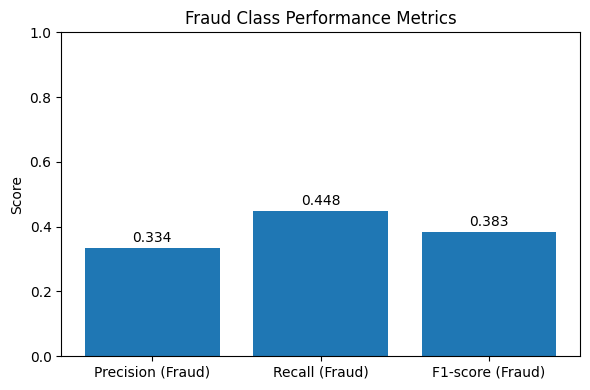

In [20]:
# Cell 20: Precision, Recall, F1 for the fraud class (1) as a bar chart

from sklearn.metrics import precision_score, recall_score, f1_score

precision_fraud = precision_score(y_test, y_pred_if, pos_label=1)
recall_fraud    = recall_score(y_test, y_pred_if, pos_label=1)
f1_fraud        = f1_score(y_test, y_pred_if, pos_label=1)

metrics_names = ["Precision (Fraud)", "Recall (Fraud)", "F1-score (Fraud)"]
metrics_vals  = [precision_fraud, recall_fraud, f1_fraud]

plt.figure(figsize=(6, 4))
bars = plt.bar(metrics_names, metrics_vals)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Fraud Class Performance Metrics")

# Add value labels on top of bars
for bar, val in zip(bars, metrics_vals):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


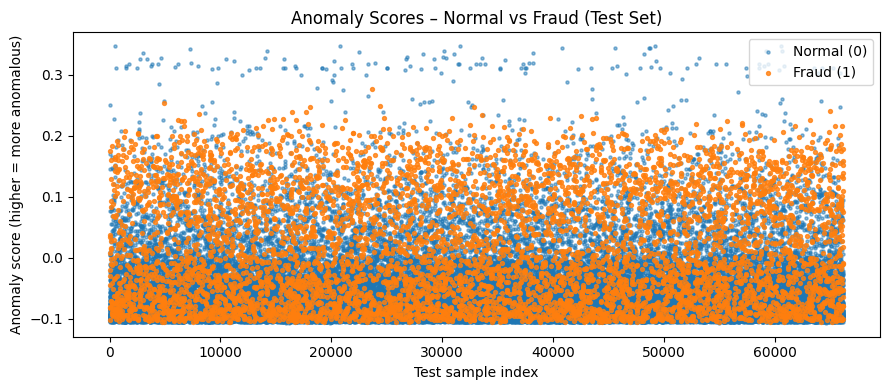

In [21]:
# Cell 21: Scatter of anomaly scores for fraud vs normal on the test set

indices = np.arange(len(anomaly_scores))
y_true_np = y_test.values

normal_idx = indices[y_true_np == 0]
fraud_idx  = indices[y_true_np == 1]

normal_scores = anomaly_scores[y_true_np == 0]
fraud_scores  = anomaly_scores[y_true_np == 1]

plt.figure(figsize=(9, 4))
plt.scatter(normal_idx, normal_scores, s=5, alpha=0.5, label="Normal (0)")
plt.scatter(fraud_idx,  fraud_scores,  s=8, alpha=0.8, label="Fraud (1)")
plt.xlabel("Test sample index")
plt.ylabel("Anomaly score (higher = more anomalous)")
plt.title("Anomaly Scores – Normal vs Fraud (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()


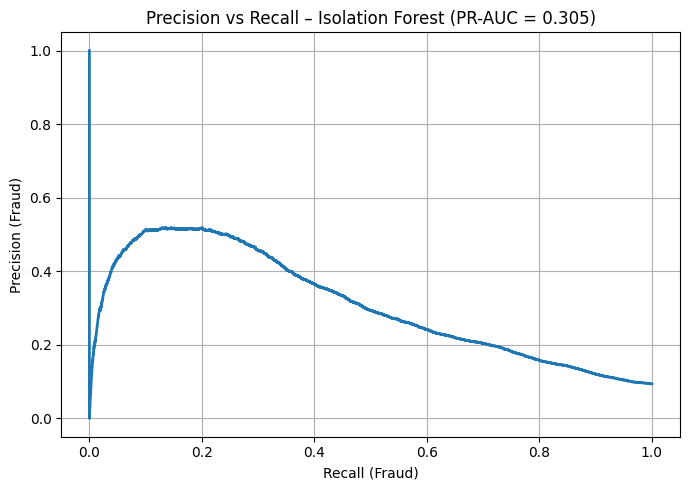

In [22]:
# Cell 22: Precision vs Recall parametric plot

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall (Fraud)")
plt.ylabel("Precision (Fraud)")
plt.title(f"Precision vs Recall – Isolation Forest (PR-AUC = {pr_auc:.3f})")
plt.grid(True)
plt.tight_layout()
plt.show()


In [23]:
# Cell 23: Save preprocessor and Isolation Forest model to disk

import joblib
import os

SAVE_DIR = "models_ieee_if"
os.makedirs(SAVE_DIR, exist_ok=True)

preprocessor_path = os.path.join(SAVE_DIR, "ieee_preprocessor.joblib")
iso_forest_path   = os.path.join(SAVE_DIR, "ieee_isolation_forest.joblib")

joblib.dump(preprocessor, preprocessor_path)
joblib.dump(iso_forest, iso_forest_path)

print("[+] Saved preprocessor to:", preprocessor_path)
print("[+] Saved Isolation Forest to:", iso_forest_path)


[+] Saved preprocessor to: models_ieee_if/ieee_preprocessor.joblib
[+] Saved Isolation Forest to: models_ieee_if/ieee_isolation_forest.joblib


In [24]:
# Cell 24: Load preprocessor + Isolation Forest and run inference on new samples

import joblib
import numpy as np

# Load back
preprocessor_loaded = joblib.load(preprocessor_path)
iso_forest_loaded   = joblib.load(iso_forest_path)

print("[+] Loaded preprocessor and Isolation Forest from disk.")

# Example "new" data: take first 20 rows of X_test (raw, unprocessed)
X_new_raw = X_test.iloc[:20].copy()
y_new_true = y_test.iloc[:20].copy()

# Transform with loaded preprocessor
X_new_processed = preprocessor_loaded.transform(X_new_raw)

# Get anomaly scores and predictions from loaded model
raw_scores_new = iso_forest_loaded.decision_function(X_new_processed)
anomaly_scores_new = -raw_scores_new
raw_pred_new = iso_forest_loaded.predict(X_new_processed)
y_new_pred = (raw_pred_new == -1).astype(int)  # 1 = fraud, 0 = normal

print("\n[+] Inference on 20 new samples:")
for i in range(len(X_new_raw)):
    print(
        f"Sample {i:02d} | Anomaly score: {anomaly_scores_new[i]:.4f} | "
        f"Pred: {y_new_pred[i]} | True: {y_new_true.iloc[i]}"
    )


[+] Loaded preprocessor and Isolation Forest from disk.

[+] Inference on 20 new samples:
Sample 00 | Anomaly score: -0.0978 | Pred: 0 | True: 0
Sample 01 | Anomaly score: -0.0206 | Pred: 0 | True: 1
Sample 02 | Anomaly score: 0.2513 | Pred: 1 | True: 0
Sample 03 | Anomaly score: -0.0680 | Pred: 0 | True: 0
Sample 04 | Anomaly score: -0.0950 | Pred: 0 | True: 0
Sample 05 | Anomaly score: -0.0444 | Pred: 0 | True: 1
Sample 06 | Anomaly score: -0.0841 | Pred: 0 | True: 0
Sample 07 | Anomaly score: -0.0852 | Pred: 0 | True: 0
Sample 08 | Anomaly score: -0.0931 | Pred: 0 | True: 0
Sample 09 | Anomaly score: -0.0937 | Pred: 0 | True: 0
Sample 10 | Anomaly score: -0.0932 | Pred: 0 | True: 0
Sample 11 | Anomaly score: -0.0886 | Pred: 0 | True: 0
Sample 12 | Anomaly score: 0.0090 | Pred: 1 | True: 0
Sample 13 | Anomaly score: -0.0957 | Pred: 0 | True: 0
Sample 14 | Anomaly score: -0.0808 | Pred: 0 | True: 1
Sample 15 | Anomaly score: -0.0219 | Pred: 0 | True: 0
Sample 16 | Anomaly score: -0.10

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.0s finished
